# ARTI308 - Machine Learning

# Linear Regression on Student Health Data

In this lab, we will apply **Linear Regression** on the **student_health_data.csv** dataset, following the same style and steps used in the lab so letss goo

## What we will do
1. Import the required libraries  
2. Load and clean the dataset  
3. Explore the data  
4. Perform simple EDA  
5. Prepare **X** and **y**  
6. Split the data into training and testing sets  
7. Train a **Linear Regression** model  
8. Interpret the model coefficients  
9. Make predictions  
10. Evaluate the model using **MAE, MSE, RMSE**  

## Target variable
In this lab, we will predict:

**Stress_Level_Biosensor**

This is a numeric value, so it is suitable for **Linear Regression**.


## Import Libraries

First, we import the libraries we need for data analysis, visualization, and machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load and Clean the Data

The uploaded file has a formatting issue:
- The header is separated by **semicolon (;)**
- The actual data rows are separated by **comma (,)**

So we will clean it first, then load it into a proper **DataFrame**.


In [2]:
rows = []

with open('student_health_data.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(';')

    for line in f:
        values = line.strip().split(',')[:15]   # keep only the real 15 columns
        rows.append(values)

df = pd.DataFrame(rows, columns=header)

df.head()

,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Biosensor,Stress_Level_Self_Report,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Family_members
0,1,24,M,50.66321699,122.173015,84.41986006,3.137349747,9.02866916,High,Moderate,Happy,34.52097288,16.80095639,Moderate,2
1,2,21,F,57.92604168,110.778407,75.69614524,3.699078337,5.819697245,Moderate,Good,Stressed,16.76384602,15.79115435,Moderate,1
2,3,22,M,59.2942192,109.3756731,83.80381448,6.785155635,5.892360174,Low,Moderate,Happy,44.20379848,25.67843705,Moderate,12
3,4,24,M,76.82623236,125.1422274,78.09158681,6.408509361,6.884001307,High,Poor,Happy,21.77664529,20.80839116,High,9
4,5,20,M,68.34276947,107.5155918,80.67493681,7.264718754,4.483450107,Moderate,Poor,Happy,8.964999083,15.194045,Moderate,7


## Check the Data

Now let's inspect the first rows, the data types, and the statistical summary.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Student_ID                1000 non-null   str  
 1   Age                       1000 non-null   str  
 2   Gender                    1000 non-null   str  
 3   Heart_Rate                1000 non-null   str  
 4   Blood_Pressure_Systolic   1000 non-null   str  
 5   Blood_Pressure_Diastolic  1000 non-null   str  
 6   Stress_Level_Biosensor    1000 non-null   str  
 7   Stress_Level_Self_Report  1000 non-null   str  
 8   Physical_Activity         1000 non-null   str  
 9   Sleep_Quality             1000 non-null   str  
 10  Mood                      1000 non-null   str  
 11  Study_Hours               1000 non-null   str  
 12  Project_Hours             1000 non-null   str  
 13  Health_Risk_Level         1000 non-null   str  
 14  Family_members            1000 non-null   str  
dtyp

In [4]:
df.describe(include='all')

,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Biosensor,Stress_Level_Self_Report,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Family_members
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,7,2,981,979,982,1000,1000,3,3,3,993,999,3,14
top,1,21,M,50,90,60,3.137349747,9.02866916,Moderate,Good,Neutral,5,0,Moderate,2
freq,1,156,519,20,22,19,1,1,491,473,415,8,2,672,81


In [5]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Heart_Rate', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Stress_Level_Biosensor',
       'Stress_Level_Self_Report', 'Physical_Activity', 'Sleep_Quality',
       'Mood', 'Study_Hours', 'Project_Hours', 'Health_Risk_Level',
       'Family_members'],
      dtype='str')

## Convert the Numeric Columns

Some columns were loaded as text during the cleaning step, so we convert the numeric columns to the correct type.


In [6]:
numeric_cols = [
    'Student_ID',
    'Age',
    'Heart_Rate',
    'Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic',
    'Stress_Level_Biosensor',
    'Stress_Level_Self_Report',
    'Study_Hours',
    'Project_Hours',
    'Family_members'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   str    
 3   Heart_Rate                1000 non-null   float64
 4   Blood_Pressure_Systolic   1000 non-null   float64
 5   Blood_Pressure_Diastolic  1000 non-null   float64
 6   Stress_Level_Biosensor    1000 non-null   float64
 7   Stress_Level_Self_Report  1000 non-null   float64
 8   Physical_Activity         1000 non-null   str    
 9   Sleep_Quality             1000 non-null   str    
 10  Mood                      1000 non-null   str    
 11  Study_Hours               1000 non-null   float64
 12  Project_Hours             1000 non-null   float64
 13  Health_Risk_Level         1000 non-null   str    
 14  Family_members      

In [7]:
df.isnull().sum()

Student_ID                  0
Age                         0
Gender                      0
Heart_Rate                  0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Stress_Level_Biosensor      0
Stress_Level_Self_Report    0
Physical_Activity           0
Sleep_Quality               0
Mood                        0
Study_Hours                 0
Project_Hours               0
Health_Risk_Level           0
Family_members              0
dtype: int64

The dataset is now clean and ready to use.

## EDA

Let's create some simple plots to better understand the data.


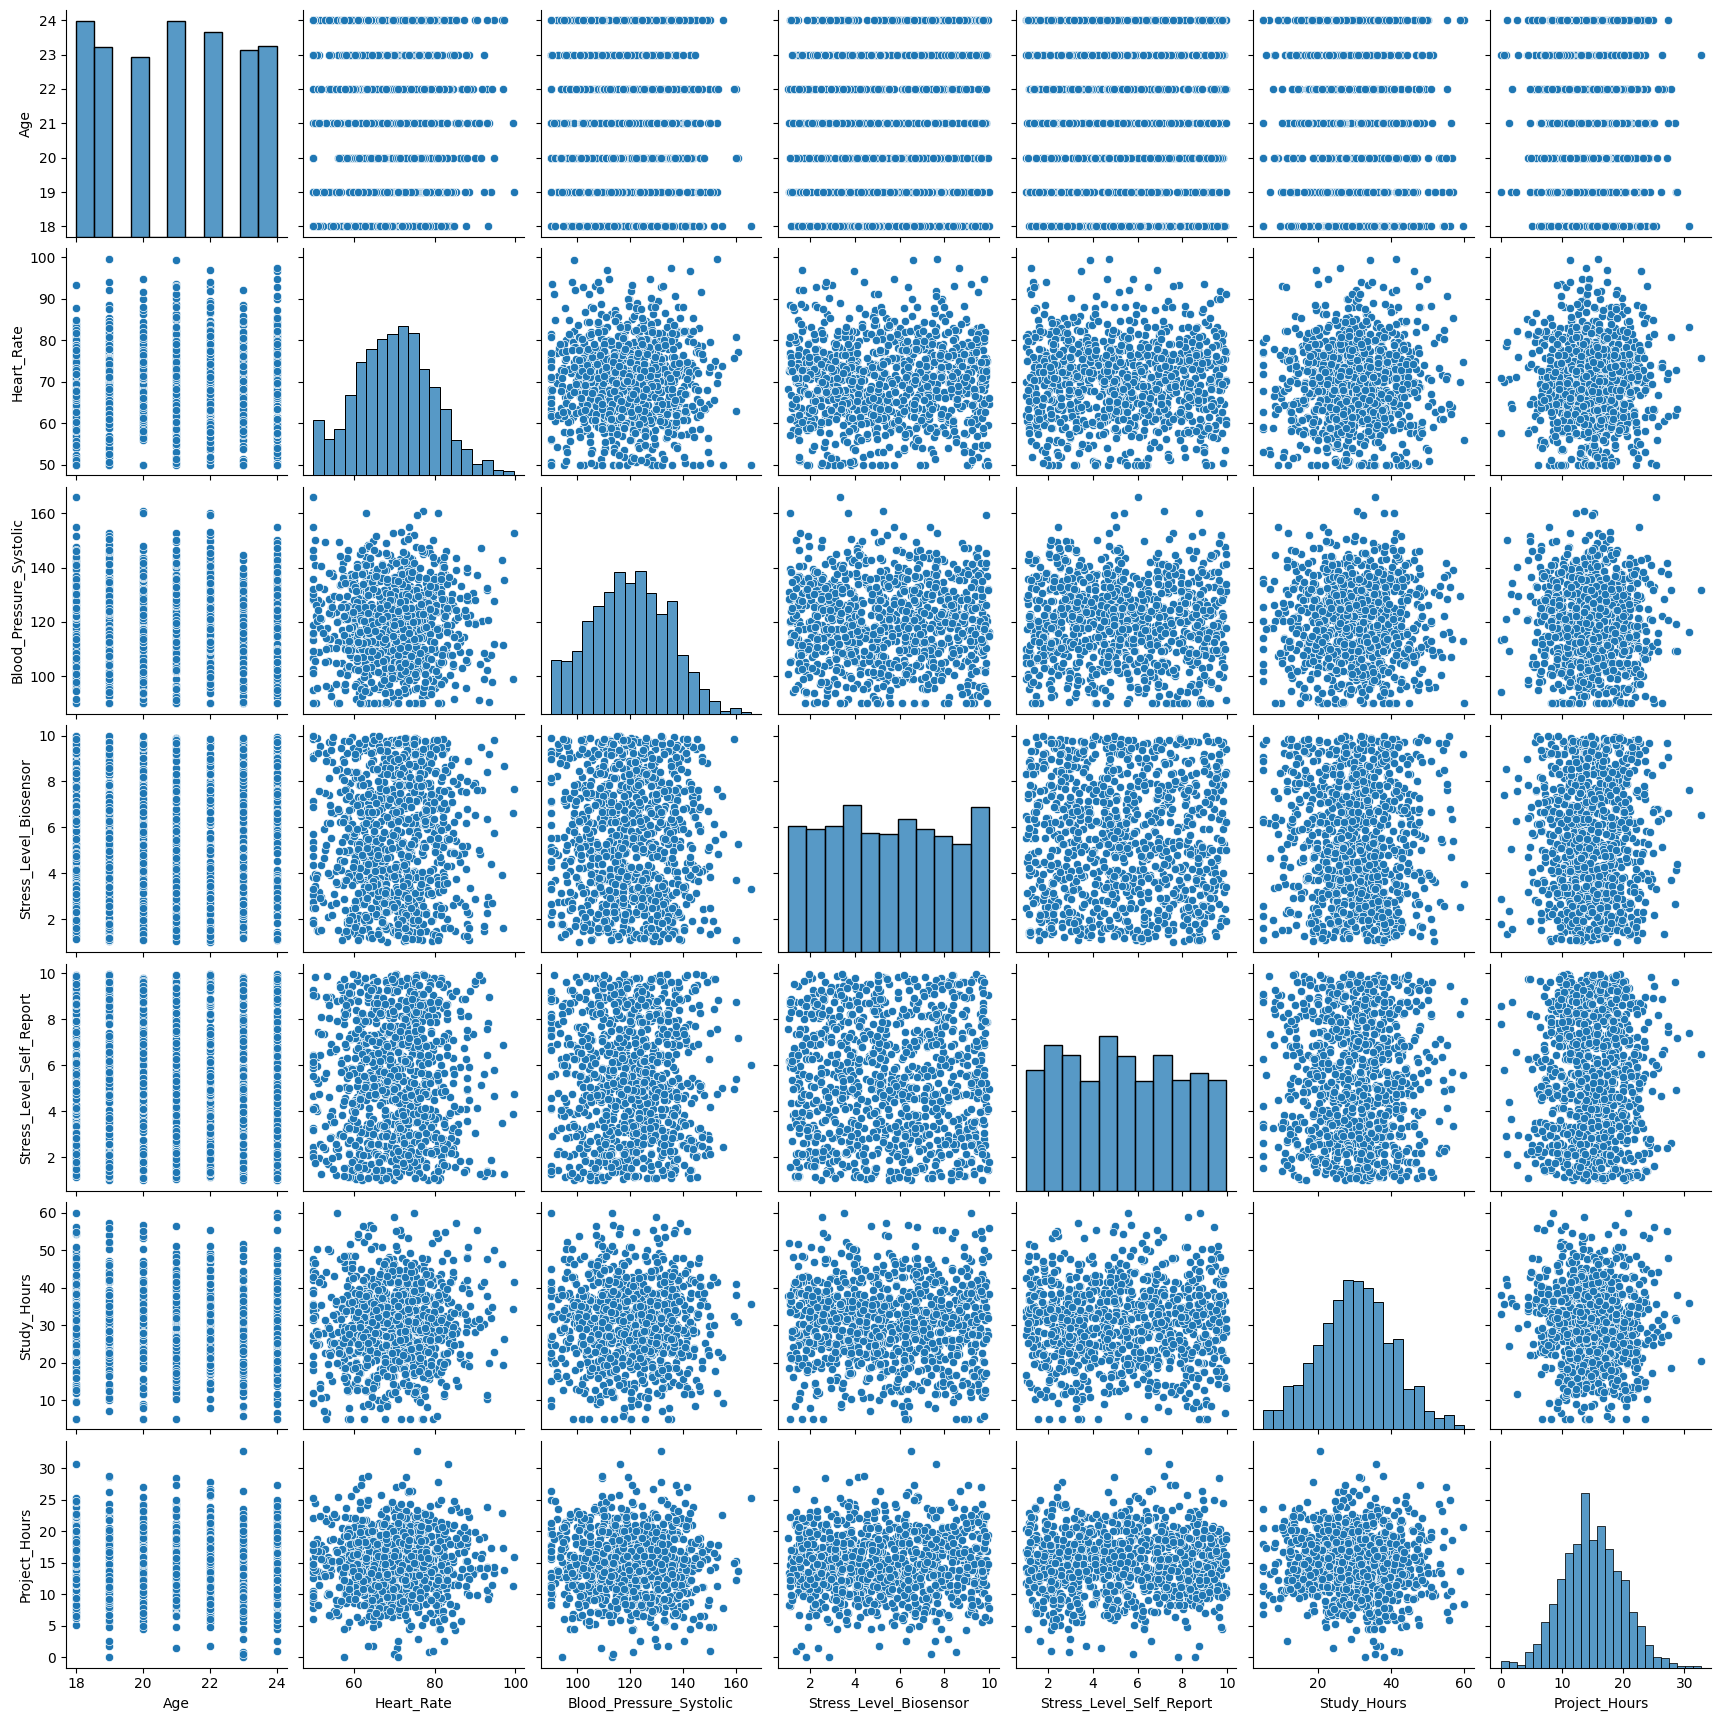

In [8]:
sns.pairplot(df[['Age',
                 'Heart_Rate',
                 'Blood_Pressure_Systolic',
                 'Stress_Level_Biosensor',
                 'Stress_Level_Self_Report',
                 'Study_Hours',
                 'Project_Hours']])
plt.show()

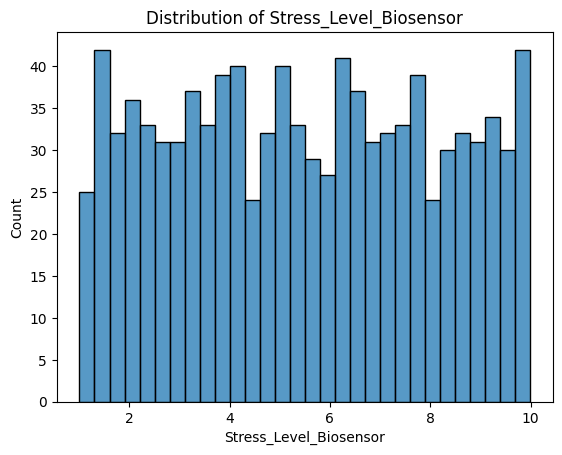

In [9]:
sns.histplot(df['Stress_Level_Biosensor'], bins=30)
plt.title('Distribution of Stress_Level_Biosensor')
plt.show()

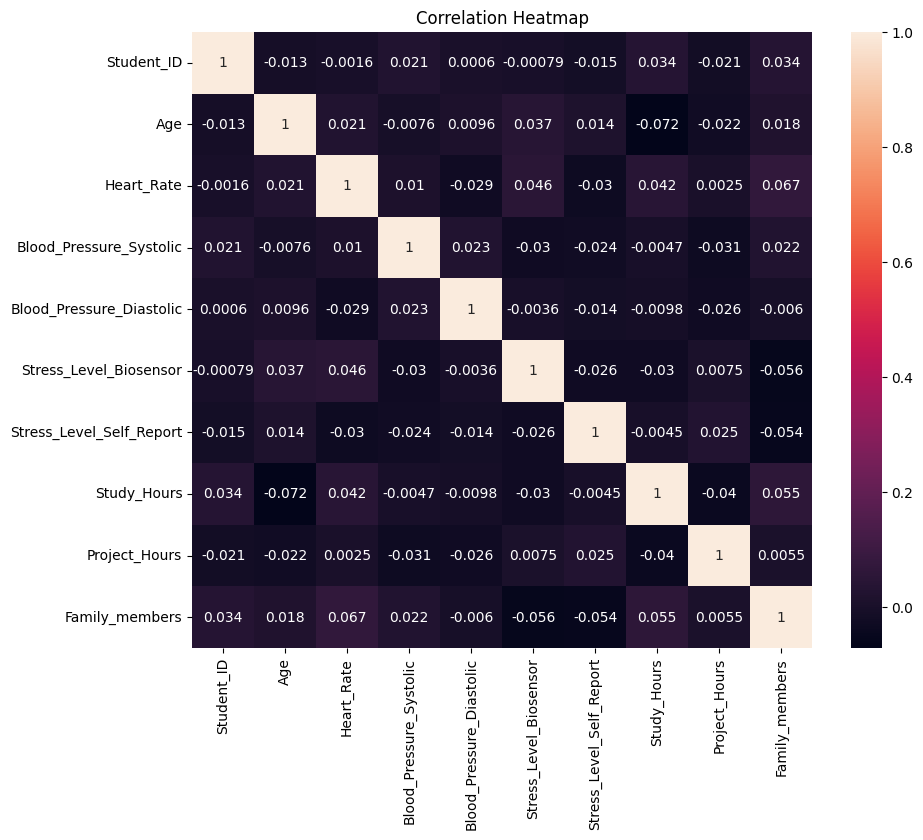

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Training a Linear Regression Model

Now we prepare the feature matrix **X** and the target vector **y**.

### Notes
- We will predict **Stress_Level_Biosensor**
- We will drop **Student_ID** because it is only an identifier and does not help prediction
- We will convert categorical columns into dummy variables using **pd.get_dummies()**


In [11]:
X = df.drop(columns=['Stress_Level_Biosensor', 'Student_ID'])
y = df['Stress_Level_Biosensor']

X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Self_Report,Study_Hours,Project_Hours,Family_members,Gender_M,Physical_Activity_Low,Physical_Activity_Moderate,Sleep_Quality_Moderate,Sleep_Quality_Poor,Mood_Neutral,Mood_Stressed,Health_Risk_Level_Low,Health_Risk_Level_Moderate
0,24,50.663217,122.173015,84.419860,9.028669,34.520973,16.800956,2,True,False,False,True,False,False,False,False,True
1,21,57.926042,110.778407,75.696145,5.819697,16.763846,15.791154,1,False,False,True,False,False,False,True,False,True
2,22,59.294219,109.375673,83.803814,5.892360,44.203798,25.678437,12,True,True,False,True,False,False,False,False,True
3,24,76.826232,125.142227,78.091587,6.884001,21.776645,20.808391,9,True,False,False,False,True,False,False,False,False
4,20,68.342769,107.515592,80.674937,4.483450,8.964999,15.194045,7,True,False,True,False,True,False,False,False,True


## Train Test Split

Now we split the data into:
- **Training set**: to train the model
- **Testing set**: to evaluate the model


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

## Creating and Training the Model


In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lm = LinearRegression()

In [16]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evaluation

Let's inspect the intercept and coefficients of the model.


In [17]:
print(lm.intercept_)

9.78970691574845


In [18]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Age,-0.004711
Heart_Rate,0.012248
Blood_Pressure_Systolic,-0.004406
Blood_Pressure_Diastolic,0.001151
Stress_Level_Self_Report,-0.370915
Study_Hours,0.002909
Project_Hours,-0.009977
Family_members,-0.006843
Gender_M,-0.129842
Physical_Activity_Low,0.788647


### Interpreting the coefficients

Each coefficient shows how a one-unit increase in that feature affects the predicted **Stress_Level_Biosensor**, while holding all other features fixed.

- Positive coefficient → increases the predicted stress level  
- Negative coefficient → decreases the predicted stress level  


## Predictions from our Model

Let's generate predictions on the test set and compare them with the actual values.


In [19]:
predictions = lm.predict(X_test)

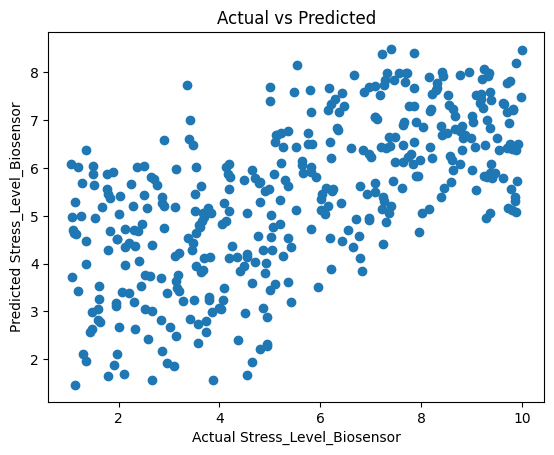

In [20]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Stress_Level_Biosensor')
plt.ylabel('Predicted Stress_Level_Biosensor')
plt.title('Actual vs Predicted')
plt.show()

**Residual Histogram**


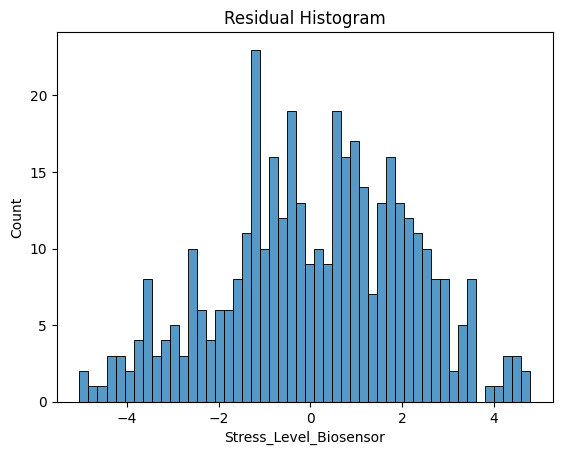

In [21]:
sns.histplot((y_test - predictions), bins=50)
plt.title('Residual Histogram')
plt.show()

## Regression Evaluation Metrics

Here are three common evaluation metrics for regression problems:

**Mean Absolute Error (MAE)** is the mean of the absolute value of the errors

**Mean Squared Error (MSE)** is the mean of the squared errors

**Root Mean Squared Error (RMSE)** is the square root of the mean squared error


In [22]:
from sklearn import metrics

In [23]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 1.6762414597609836
MSE: 4.164678643580637
RMSE: 2.0407544300039233


## in the edn of this lab Note

This code follows the same general workflow used in the original lab but it is applied my **student_health_data.csv** 

### Summary
- We cleaned the dataset
- We explored and visualized the data
- We trained a **Linear Regression** model
- We predicted **Stress_Level_Biosensor**
- We evaluated the model using **MAE, MSE, and RMSE**

Thats it Byyy|